# Price-based features

Mid, rolling volatility (`vol_50`), and microprice tilt over a 10-minute window.

In [1]:
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("cwd:", Path.cwd())

cwd: /home/johnh/projects/microstructure-benchmark


In [2]:
import matplotlib.pyplot as plt
import polars as pl
from src.features import add_returns, add_rolling_vol, add_microprice_tilt

lf = pl.scan_parquet("data/parquet/mnq_bars100ms_2025-09-15.parquet").filter(
    (pl.col("ts_event") >= pl.lit("2025-09-15T14:00:00").str.to_datetime(time_zone="UTC"))
    & (pl.col("ts_event") < pl.lit("2025-09-15T14:10:00").str.to_datetime(time_zone="UTC"))
)
df = add_microprice_tilt(add_rolling_vol(add_returns(lf), [50])).collect()
print("rows:", df.height)

rows: 5936


saved: /home/johnh/projects/microstructure-benchmark/notebooks/figures/features_10min.png


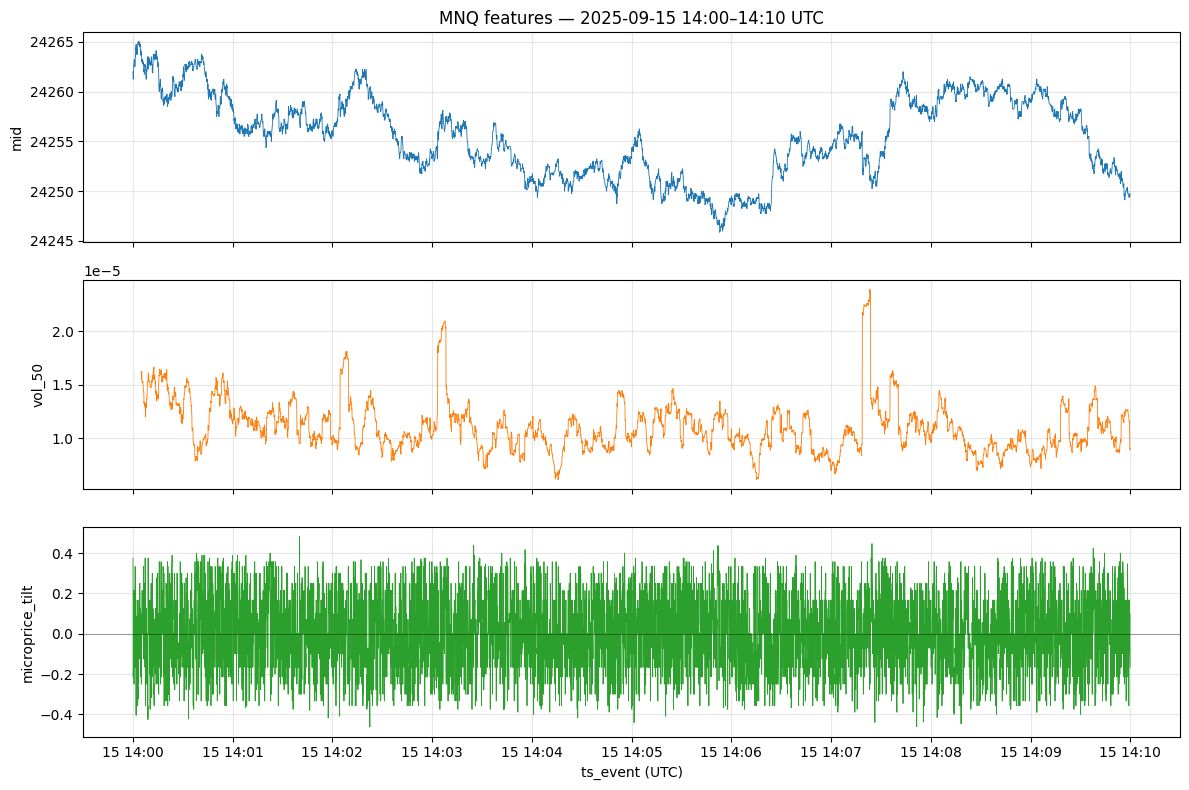

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df["ts_event"], df["mid"], linewidth=0.6)
axes[0].set_ylabel("mid")
axes[0].set_title("MNQ features — 2025-09-15 14:00–14:10 UTC")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["ts_event"], df["vol_50"], linewidth=0.6, color="C1")
axes[1].set_ylabel("vol_50")
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["ts_event"], df["microprice_tilt"], linewidth=0.6, color="C2")
axes[2].set_ylabel("microprice_tilt")
axes[2].set_xlabel("ts_event (UTC)")
axes[2].axhline(0, color="k", linewidth=0.5, alpha=0.5)
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
out = Path("notebooks/figures/features_10min.png")
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=120)
print("saved:", out.resolve())
plt.show()

# Order flow imbalance vs forward return

`ofi_sum_1000ms` vs 1-second forward mid log-return. Expect a **positive** correlation.

corr=-0.0054 n=20,374
saved: /home/johnh/projects/microstructure-benchmark/notebooks/figures/ofi_vs_fwd_return.png


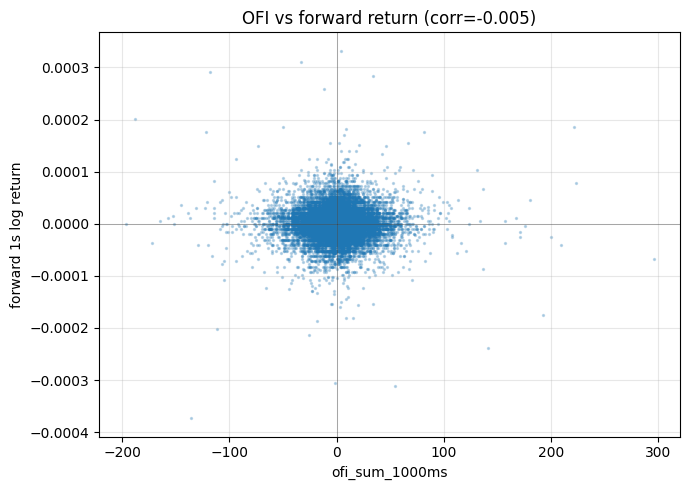

In [4]:
import numpy as np

lf = pl.scan_parquet("data/parquet/mnq_bars100ms_2025-09-15.parquet")
df = (
    lf.with_columns(
        (pl.col("mid").shift(-10) / pl.col("mid")).log().alias("fwd_ret_1s")
    )
    .select(["ofi_sum_1000ms", "fwd_ret_1s"])
    .drop_nulls()
    .collect()
)
step = max(1, df.height // 20_000)
plot = df[::step]
corr = np.corrcoef(plot["ofi_sum_1000ms"].to_numpy(), plot["fwd_ret_1s"].to_numpy())[0, 1]
print(f"corr={corr:.4f} n={plot.height:,}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot["ofi_sum_1000ms"], plot["fwd_ret_1s"], s=2, alpha=0.25)
ax.set_xlabel("ofi_sum_1000ms")
ax.set_ylabel("forward 1s log return")
ax.set_title(f"OFI vs forward return (corr={corr:.3f})")
ax.axhline(0, color="k", lw=0.5, alpha=0.4)
ax.axvline(0, color="k", lw=0.5, alpha=0.4)
ax.grid(True, alpha=0.3)
fig.tight_layout()
out = Path("notebooks/figures/ofi_vs_fwd_return.png")
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=120)
print("saved:", out.resolve())
plt.show()